# 量子テレポーテーション
IBM Quantum Learningに掲載されているQiskitコードを参考にしています
まずは量子テレポーテーションの実装に必要なライブラリのインストールします

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

## 量子テレポーテーションの実装
実際に量子テレポーテーションを量子回路上に実装します。
以下の実装では、AliceとBobに量子もつれ状態であるベル状態を持たせるための回路（HとCNOT）から始まっています。

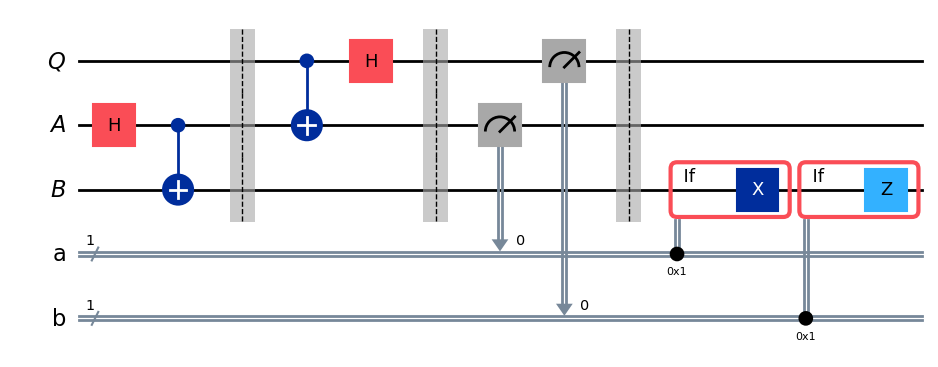

In [3]:
#量子ビットおよび古典ビットの用意
q = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(q, ebit0, ebit1, a, b)

#AliceとBobにベル状態を持たせる
protocol.h(ebit0)
protocol.cx(ebit0, ebit1) #control, targetの順番
protocol.barrier() #barrierは仕切りを設けて量子回路を見やすくする

#----ここからが量子テレポーテーション----
#Aliceの操作
protocol.cx(q, ebit0)
protocol.h(q)
protocol.barrier()

#Aliceの測定結果を古典通信でBobに伝える
protocol.measure(ebit0, a)
protocol.measure(q, b)
protocol.barrier()

#Aliceから送られてきた古典通信の結果に応じてBobがゲート操作
with protocol.if_test((a, 1)):
    protocol.x(ebit1) #量子ビットebit0の測定で1が出たらXゲートをかける
with protocol.if_test((b, 1)):
    protocol.z(ebit1) #量子ビットqの測定で1が出たらZゲートをかける

display(protocol.draw(output = "mpl"))

## 量子テレポーテーションのテスト
量子テレポーテーションがうまくいっていることを確認します。
その確認方法としてユニタリ変換Uとその逆変換```U^{-1}=(U^{\dagger})```を用いる。```math\ket{0}```にユニタリゲートをかけ、その状態をBobにテレポーテーションする。最後にBobが持っている状態にUの逆変換をかけて必ず```math\ket{0}```になればテレポーテーションが成功したことを意味する。

In [5]:
#ランダムなユニタリゲートの生成
random_gate = UGate(
    theta = random.random() * 2 * pi,
    phi = random.random() * 2 * pi,
    lam = random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

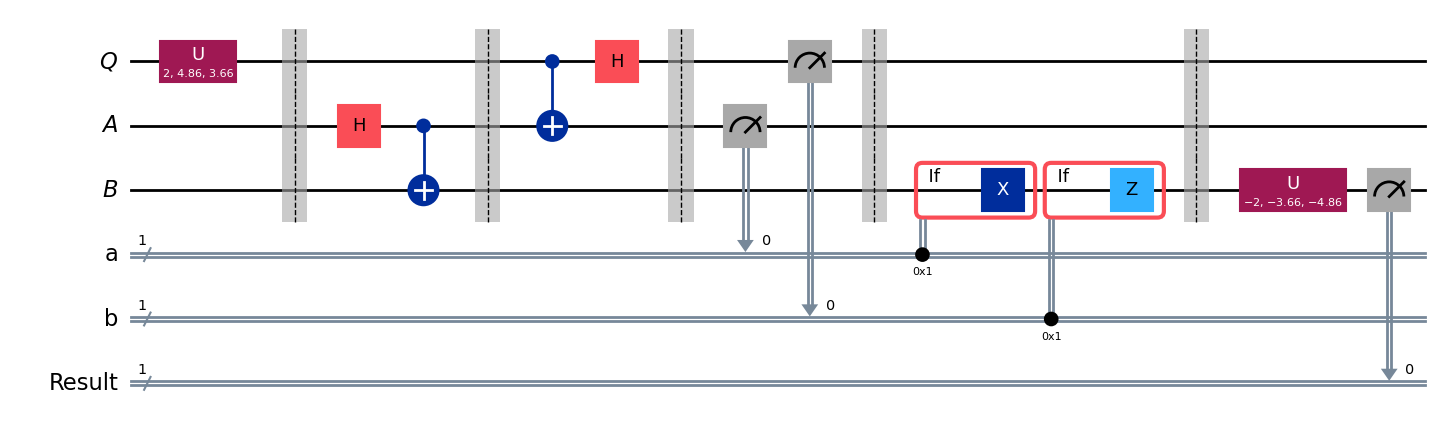

In [7]:
#量子テレポーテーションのテスト回路
test = QuantumCircuit(q, ebit0, ebit1, a, b)

#まずqに対して先ほど作ったランダムなユニタリゲートを作用させる
test.append(random_gate, q)
test.barrier()

#次に量子テレポーテーションの回路であるprotocolを合成する
test = test.compose(protocol)
test.barrier()

#最後にBobがもつ量子ビットに対してrandom_gateの逆ゲートをかける
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result) #古典ビット"result"を回路に追加
test.measure(ebit1, result)

display(test.draw(output = "mpl"))

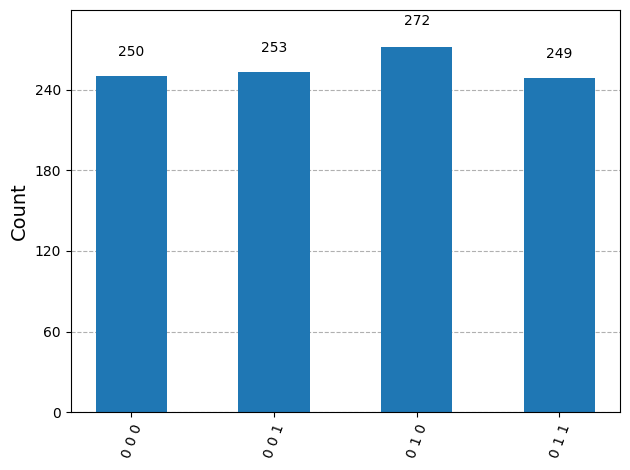

In [8]:
#AerSimulatorを用いてシミュレーション
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

量子ビットの測定結果が左からresult,b,aとなっており、resultはすべて0になっていることがわかります。
これは量子テレポーテーションが成功している証拠であるといえます。

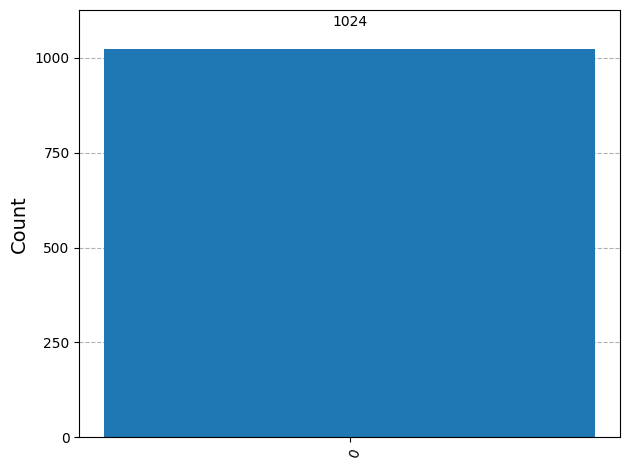

In [9]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))